# 데이터 탐색 — 애니 캐릭터 데이터셋

## 메타데이터 로드

In [12]:
df = pl.read_csv('../data/processed/metadata.csv')
print(f'총 이미지: {len(df)}장 / 캐릭터: {df["캐릭터"].n_unique()}명 / 애니메이션: {df["애니메이션"].n_unique()}작품')
df.head(10)

총 이미지: 1432장 / 캐릭터: 15명 / 애니메이션: 11작품


id,애니메이션,캐릭터,사진_경로
i64,str,str,str
0,"""강철의 연금술사""","""Elric Edward""","""data/processed/Elric Edward - …"
1,"""강철의 연금술사""","""Elric Edward""","""data/processed/Elric Edward - …"
2,"""강철의 연금술사""","""Elric Edward""","""data/processed/Elric Edward - …"
3,"""강철의 연금술사""","""Elric Edward""","""data/processed/Elric Edward - …"
4,"""강철의 연금술사""","""Elric Edward""","""data/processed/Elric Edward - …"
5,"""강철의 연금술사""","""Elric Edward""","""data/processed/Elric Edward - …"
6,"""강철의 연금술사""","""Elric Edward""","""data/processed/Elric Edward - …"
7,"""강철의 연금술사""","""Elric Edward""","""data/processed/Elric Edward - …"
8,"""강철의 연금술사""","""Elric Edward""","""data/processed/Elric Edward - …"


## 애니메이션별 이미지 수

In [13]:
anime_counts = (
    df.group_by('애니메이션')
    .agg(pl.len().alias('이미지수'), pl.col('캐릭터').n_unique().alias('캐릭터수'))
    .sort('이미지수', descending=True)
)
display(anime_counts)

애니메이션,이미지수,캐릭터수
str,u32,u32
"""원피스""",242,2
"""드래곤볼""",198,2
"""헌터x헌터""",184,2
"""나루토""",156,2
"""블리치""",100,1
…,…,…
"""은혼""",94,1
"""코드 기아스 반역의 를르슈""",92,1
"""강철의 연금술사""",91,1


## 캐릭터별 이미지 수

캐릭터,애니메이션,이미지수
str,str,u32
"""Luffy""","""원피스""",143
"""Ichigo""","""블리치""",100
"""Goku""","""드래곤볼""",100
"""Zoro""","""원피스""",99
"""Light Yagami""","""데스노트""",99
…,…,…
"""Elric Edward""","""강철의 연금술사""",91
"""Natsu Dragneel""","""페어리 테일""",88
"""Eren Yeager""","""진격의 거인""",88


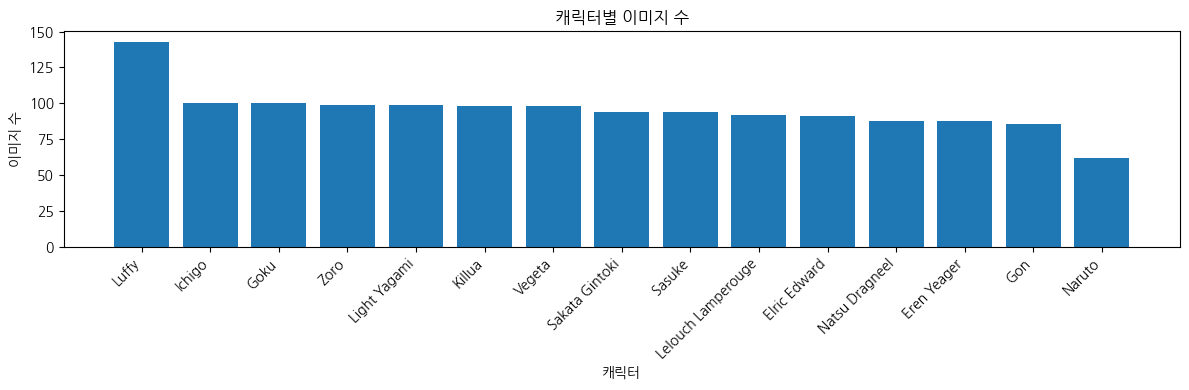

In [14]:
char_counts = (
    df.group_by(['캐릭터', '애니메이션'])
    .agg(pl.len().alias('이미지수'))
    .sort('이미지수', descending=True)
)
display(char_counts)

fig, ax = plt.subplots(figsize=(12, 4))
labels = char_counts['캐릭터'].to_list()
values = char_counts['이미지수'].to_list()
ax.bar(labels, values)
ax.set_xlabel('캐릭터')
ax.set_ylabel('이미지 수')
ax.set_title('캐릭터별 이미지 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 캐릭터 필터링

In [15]:
# 원하는 캐릭터/애니로 바꿔서 조회
TARGET_CHAR = 'Naruto'

subset = df.filter(pl.col('캐릭터') == TARGET_CHAR)
print(f'{TARGET_CHAR}: {len(subset)}장')
display(subset.head(10))

Naruto: 62장


id,애니메이션,캐릭터,사진_경로
i64,str,str,str
897,"""나루토""","""Naruto""","""data/processed/Naruto - 나루토…"
898,"""나루토""","""Naruto""","""data/processed/Naruto - 나루토…"
899,"""나루토""","""Naruto""","""data/processed/Naruto - 나루토…"
900,"""나루토""","""Naruto""","""data/processed/Naruto - 나루토…"
901,"""나루토""","""Naruto""","""data/processed/Naruto - 나루토…"
902,"""나루토""","""Naruto""","""data/processed/Naruto - 나루토…"
903,"""나루토""","""Naruto""","""data/processed/Naruto - 나루토…"
904,"""나루토""","""Naruto""","""data/processed/Naruto - 나루토…"
905,"""나루토""","""Naruto""","""data/processed/Naruto - 나루토…"


## 샘플 이미지 미리보기

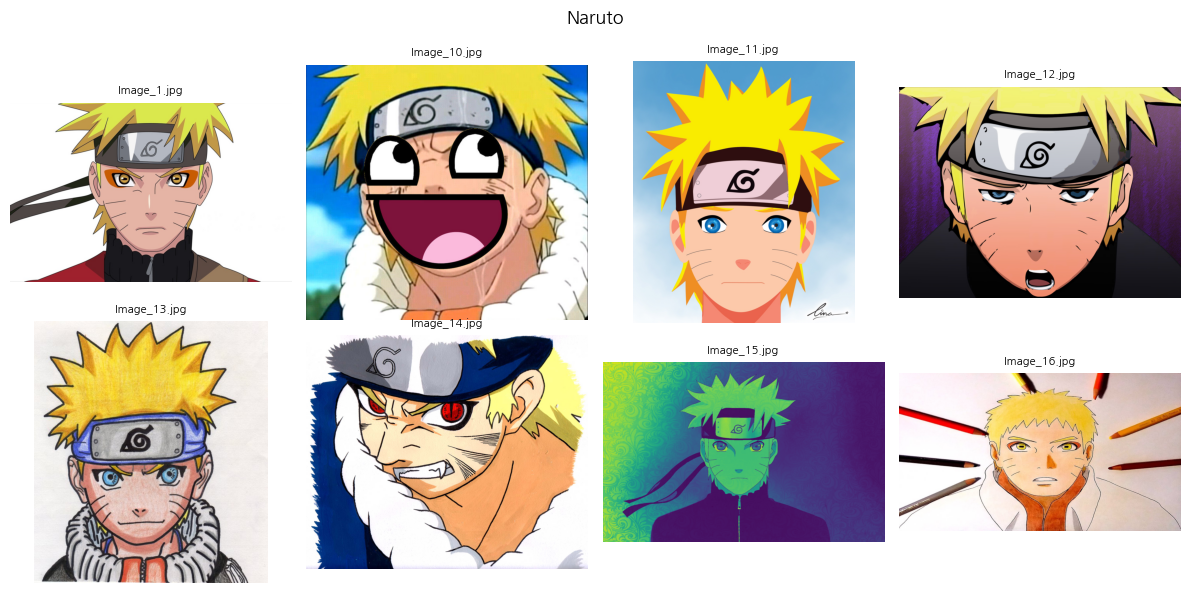

In [16]:
def show_samples(character: str, n: int = 8):
    paths = (
        df.filter(pl.col('캐릭터') == character)
        .head(n)
        ['사진_경로']
        .to_list()
    )
    cols = min(n, 4)
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = [axes] if rows * cols == 1 else axes.flatten()
    for ax, path in zip(axes, paths):
        ax.imshow(mpimg.imread(f'../{path}'))
        ax.axis('off')
        ax.set_title(Path(path).name, fontsize=8)
    for ax in axes[len(paths):]:
        ax.axis('off')
    fig.suptitle(character, fontsize=13)
    plt.tight_layout()
    plt.show()

show_samples('Naruto')

## 전체 캐릭터 대표 이미지

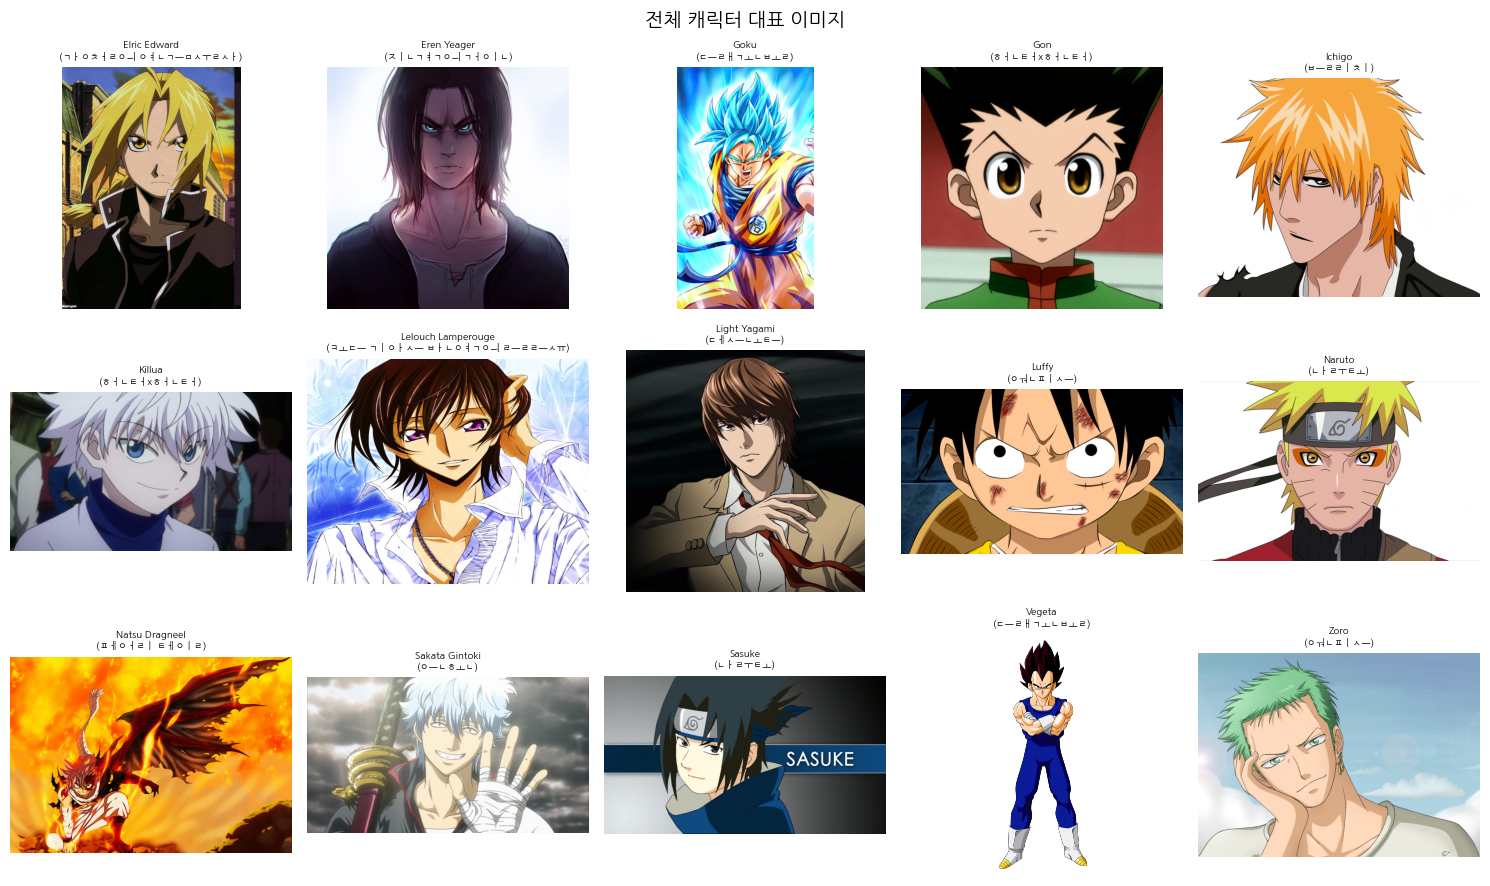

In [17]:
chars = df['캐릭터'].unique().sort().to_list()
cols = 5
rows = (len(chars) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for ax, char in zip(axes, chars):
    path = df.filter(pl.col('캐릭터') == char)['사진_경로'][0]
    anime = df.filter(pl.col('캐릭터') == char)['애니메이션'][0]
    ax.imshow(mpimg.imread(f'../{path}'))
    ax.axis('off')
    ax.set_title(f'{char}\n({anime})', fontsize=7)

for ax in axes[len(chars):]:
    ax.axis('off')

plt.suptitle('전체 캐릭터 대표 이미지', fontsize=14)
plt.tight_layout()
plt.show()